In [9]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot  as plt
import numpy as np

In [10]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [11]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3750s 22us/step


c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [12]:
x_train.shape

(50000, 32, 32, 3)

In [14]:
x_train[0].shape

(32, 32, 3)

In [15]:
y_train[0:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [16]:
def plot_sample(index):
  plt.figure(figsize=(10,2))
  plt.imshow(x_train[index])

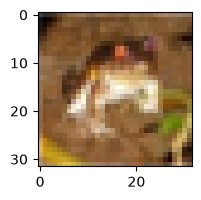

In [17]:
plot_sample(0)

In [18]:
classes=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [19]:
classes[y_train[3][0]]

'deer'

In [20]:
x_train_scaled=x_train/255
x_test_scaled=x_test/255

In [21]:
x_train_scaled.shape

(50000, 32, 32, 3)

In [22]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [28]:
import tensorflow as tf

y_train_categorical = tf.keras.utils.to_categorical(
    y_train, num_classes=10
)

y_train_categorical[:5]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [29]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [30]:
y_train_categorical

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(50000, 10))

In [33]:
model=keras.Sequential([
  keras.layers.Flatten(input_shape=(32,32,3)),
  keras.layers.Dense(3000,activation='relu'),
  keras.layers.Dense(1000,activation='relu'),
  keras.layers.Dense(10,activation='sigmoid')
])
model.compile(optimizer='SGD',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train_scaled,y_train_categorical,epochs=5)

c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.3558 - loss: 1.8098
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 42ms/step - accuracy: 0.4277 - loss: 1.6234
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 54ms/step - accuracy: 0.4558 - loss: 1.5455
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 145s 56ms/step - accuracy: 0.4741 - loss: 1.4840
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.4949 - loss: 1.4350


In [39]:
np.argmax(model.predict(x_test_scaled)[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


np.int64(3)

classes[y_test[0][0]]

In [40]:
y_test[0]

array([3], dtype=uint8)